In [12]:
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from dotenv import load_dotenv
from matplotlib.lines import Line2D
from shapely.geometry import box
from src.constants import STATE_CONFIG
from src.datasources import grrr, hydrosheds
from src.utils.rp_calc import calculate_one_group_rp

load_dotenv()

STATE = "Adamawa"
cfg = STATE_CONFIG[STATE]

ANALYSIS_START_YEAR = cfg["analysis_start_year"]
ANALYSIS_END_YEAR = cfg["analysis_end_year"]
WET_MONTHS = [8, 9, 10, 11]

STATION_RP_LEVELS = [2, 5, 7]       # Google RP levels used as station-level thresholds
FRACTION_THRESHOLDS = [0.2, 0.4, 0.6, 0.8, 1.0]  # fraction of stations required

# Floodscan RP levels used as the 'truth' for performance evaluation
FS_RP_LEVELS = [3, 4, 5]

## Station discovery

Find all Google GRRR gauges that fall within the selected riverine LGAs for the state.
These LGAs are defined in `STATE_CONFIG` and used consistently across notebooks.

In [13]:
# Load LGA boundaries and filter to this state's selected LGAs
gdf_lga = stratus.codab.load_codab_from_blob("NGA", admin_level=2)
gdf_selected = gdf_lga[gdf_lga["ADM2_PCODE"].isin(cfg["lga_pcodes"])].copy()

print(f"Selected LGAs ({len(gdf_selected)}): {sorted(gdf_selected['ADM2_EN'].tolist())}")

# Find all GRRR gauges within those LGAs — include unverified stations
gdf_stations = grrr.get_gauges_by_area(
    gdf_selected,
    include_non_quality_verified=True,
)
gauge_ids = gdf_stations["gauge_id"].tolist()

print(f"\nGRRR stations found: {len(gauge_ids)}")
print(gdf_stations[["gauge_id", "site_name", "river", "quality_verified"]].to_string(index=False))

Selected LGAs (7): ['Demsa', 'Fufore', 'Girei', 'Lamurde', 'Numan', 'Yola North', 'Yola South']

GRRR stations found: 42
        gauge_id site_name river  quality_verified
hybas_1120834480                             False
hybas_1120835110                             False
hybas_1120835720                             False
hybas_1120836240                             False
hybas_1120837500           Benue             False
hybas_1120837510           Benue             False
hybas_1120837740           Benue             False
hybas_1120837770           Benue             False
hybas_1120838030           Benue             False
hybas_1120838040                             False
hybas_1120838270           Benue             False
hybas_1120838280           Benue             False
hybas_1120838490           Benue             False
hybas_1120838680                             False
hybas_1120839560           Benue             False
hybas_1120840560           Benue             False
hybas_112084

## Station map

Locations of all Google GRRR gauges within the selected riverine LGAs, overlaid on the Benue river network.

/var/folders/rv/xmclt0vn5y7cqt46s5xq3h080000gn/T/ipykernel_23257/4018505605.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (gdf_rivers.geometry.centroid.x > cfg["river_x_min"])
/var/folders/rv/xmclt0vn5y7cqt46s5xq3h080000gn/T/ipykernel_23257/4018505605.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  & (gdf_rivers.geometry.centroid.y < 10)


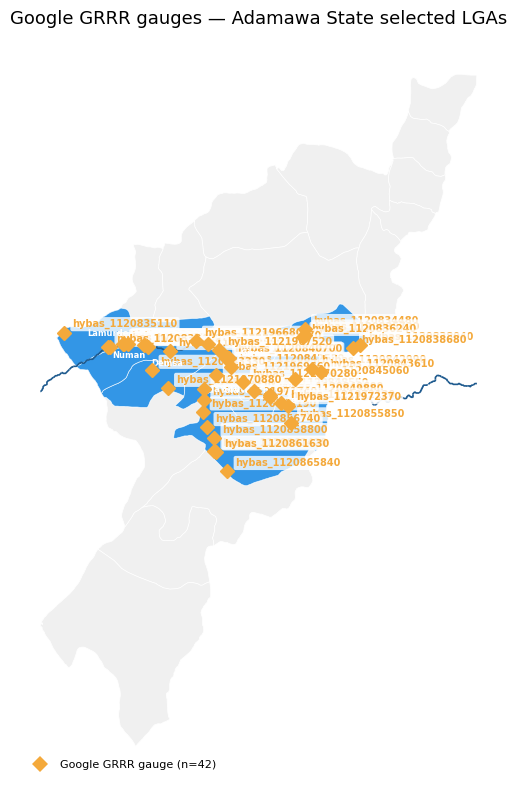

In [14]:
gdf_state = gdf_lga[gdf_lga[cfg["adm1_col"]] == cfg["adm1_val"]].copy()
gdf_non_selected = gdf_state[~gdf_state["ADM2_PCODE"].isin(cfg["lga_pcodes"])]

gdf_rivers = hydrosheds.load_selected_rivers()
gdf_benue_river = gdf_rivers[
    (gdf_rivers.geometry.centroid.x > cfg["river_x_min"])
    & (gdf_rivers.geometry.centroid.y < 10)
].copy()
minx, _, maxx, _ = gdf_state.total_bounds
gdf_river_clipped = gpd.clip(gdf_benue_river, box(minx, -90, maxx, 90))

fig, ax = plt.subplots(figsize=(10, 8))

gdf_non_selected.plot(ax=ax, color="#F0F0F0", edgecolor="white", linewidth=0.5)
gdf_selected.plot(ax=ax, color="#007CE0", edgecolor="white", linewidth=0.5, alpha=0.8)
gdf_river_clipped.plot(ax=ax, color="#1E5A8E", linewidth=1.2, zorder=3)

for _, row in gdf_stations.iterrows():
    ax.plot(row.geometry.x, row.geometry.y, marker="D", color="#F4A93B", markersize=7, zorder=5)
    label = row.get("site_name") if row.get("site_name") else row["gauge_id"]
    ax.annotate(
        label,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 4), textcoords="offset points",
        fontsize=7, color="#F4A93B", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8),
    )

for _, row in gdf_selected.iterrows():
    ax.annotate(
        row["ADM2_EN"],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        fontsize=6, ha="center", color="white", fontweight="bold",
    )

ax.legend(
    handles=[
        Line2D([0], [0], marker="D", color="w", markerfacecolor="#F4A93B",
               markersize=8, markeredgewidth=0, label=f"Google GRRR gauge (n={len(gdf_stations)})"),
    ],
    frameon=False, fontsize=8, loc="lower left",
)

ax.set_axis_off()
ax.set_title(f"Google GRRR gauges — {STATE} State selected LGAs", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

## Load reanalysis for all stations

Load Google GRRR reanalysis streamflow for every discovered station. Filter to wet-season
months and the analysis period.

In [15]:
# Load reanalysis for all stations in one call
ds_ra = grrr.load_reanalysis(gauge=gauge_ids)
df_ra = grrr.process_reanalysis(ds_ra)

df_ra["valid_time"] = pd.to_datetime(df_ra["valid_time"])
df_ra["year"] = df_ra["valid_time"].dt.year

# Wet-season filter
df_ra_wet = df_ra[
    df_ra["valid_time"].dt.month.isin(WET_MONTHS)
    & df_ra["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
].copy()

print(f"Records loaded: {len(df_ra_wet):,}")
print(f"Stations: {df_ra_wet['gauge_id'].nunique()}")
print(f"Year range: {df_ra_wet['year'].min()}–{df_ra_wet['year'].max()}")

Records loaded: 133,224
Stations: 42
Year range: 1998–2023


## Google return period thresholds

Load Google's official pre-computed return period thresholds for each station. These are
station-specific streamflow values corresponding to the 2-, 5-, and 20-year return periods,
normalising for differences in catchment size and baseline flow across gauges.

`STATION_RP_LEVELS` is set dynamically from whatever return periods Google provides.

In [16]:
# Load Google's official return period thresholds for all stations
ds_google_rp = grrr.load_return_periods(gauge=gauge_ids)

# Inspect raw structure so we can handle whatever format the zarr uses
print("=== Raw xarray Dataset ===")
print(ds_google_rp)
print("\nDimensions :", dict(ds_google_rp.dims))
print("Coordinates:", list(ds_google_rp.coords))
print("Data vars  :", list(ds_google_rp.data_vars))

# Convert to long-format DataFrame: (gauge_id, return_period, threshold)
# Case A: return_period is a dimension/coordinate → standard conversion works
# Case B: separate variables per RP (e.g. "year_2", "year_5") → melt into long form
df_raw = ds_google_rp.to_dataframe().reset_index()
print("\n=== Raw DataFrame (first rows) ===")
print(df_raw.head(10))
print("Columns:", df_raw.columns.tolist())

if "return_period" in df_raw.columns:
    # Case A
    df_google_rp = df_raw.copy()
    rp_value_col = [c for c in df_google_rp.columns if c not in ("gauge_id", "return_period")][0]
else:
    # Case B: detect numeric RP columns and melt
    id_cols = [c for c in df_raw.columns if not any(ch.isdigit() for ch in c) or c == "gauge_id"]
    rp_cols = [c for c in df_raw.columns if c not in id_cols]
    rp_value_col = "threshold"
    df_google_rp = df_raw.melt(
        id_vars=id_cols, value_vars=rp_cols,
        var_name="return_period_raw", value_name=rp_value_col,
    )
    df_google_rp["return_period"] = (
        df_google_rp["return_period_raw"].str.extract(r"(\d+)").astype(int)
    )
    df_google_rp = df_google_rp.drop(columns=["return_period_raw"])

# Filter to the RP levels defined in STATION_RP_LEVELS
df_google_rp = df_google_rp[df_google_rp["return_period"].isin(STATION_RP_LEVELS)].copy()

print(f"\nRP value column: '{rp_value_col}'")
print(df_google_rp.groupby("return_period")[rp_value_col].describe().round(1))

# Annual wet-season max per station
df_annual = (
    df_ra_wet.groupby(["gauge_id", "year"])["streamflow"]
    .max()
    .reset_index()
)
print(f"\nYears of data per station:")
print(df_annual.groupby("gauge_id")["year"].count().to_string())

=== Raw xarray Dataset ===
<xarray.Dataset> Size: 4kB
Dimensions:            (gauge_id: 42)
Coordinates:
  * gauge_id           (gauge_id) object 336B 'hybas_1120834480' ... 'hybas_1...
Data variables:
    return_period_10   (gauge_id) float64 336B 115.8 39.26 142.5 ... 46.61 49.97
    return_period_100  (gauge_id) float64 336B 195.1 61.34 239.9 ... 77.48 85.3
    return_period_15   (gauge_id) float64 336B 129.8 43.48 159.8 ... 51.98 55.91
    return_period_2    (gauge_id) float64 336B 56.76 19.73 69.05 ... 24.09 25.94
    return_period_20   (gauge_id) float64 336B 139.6 46.37 172.0 ... 55.79 60.18
    return_period_200  (gauge_id) float64 336B 219.3 67.29 269.2 ... 87.13 96.92
    return_period_25   (gauge_id) float64 336B 147.3 48.56 181.4 ... 58.75 63.53
    return_period_5    (gauge_id) float64 336B 91.49 31.57 112.3 ... 37.34 39.89
    return_period_50   (gauge_id) float64 336B 171.1 55.12 210.7 ... 68.03 74.19
    return_period_7    (gauge_id) float64 336B 103.4 35.39 127.1 ... 4

/var/folders/rv/xmclt0vn5y7cqt46s5xq3h080000gn/T/ipykernel_23257/1295884123.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("\nDimensions :", dict(ds_google_rp.dims))


## Annual exceedance matrix

For each station-year, flag whether the annual wet-season max exceeded the N-year RP
threshold. This produces a binary (station × year) exceedance matrix for each RP level.

Then compute the **fraction of stations exceeding** in each year — this is the key quantity
used to define the ensemble trigger.

In [17]:
# For each RP level: fraction of stations exceeding Google's threshold in each year
# Result: dict {rp: pd.Series(year -> fraction_exceeded)}
frac_exceeded = {}
for rp in STATION_RP_LEVELS:
    # Google threshold for this RP level, keyed by gauge_id
    rp_thresh = (
        df_google_rp[df_google_rp["return_period"] == rp]
        .set_index("gauge_id")[rp_value_col]
        .rename("rp_threshold")
    )

    # Join annual max with the gauge-specific RP threshold
    df_check = df_annual.join(rp_thresh, on="gauge_id")
    df_check["triggered"] = (df_check["streamflow"] > df_check["rp_threshold"]).astype(int)

    frac_by_year = df_check.groupby("year")["triggered"].mean()
    frac_exceeded[rp] = frac_by_year

# Quick check
for rp, frac in frac_exceeded.items():
    print(f"RP {rp}yr — years with ≥1 station triggered: {(frac > 0).sum()}, "
          f"years with all stations triggered: {(frac == 1.0).sum()}")

RP 2yr — years with ≥1 station triggered: 19, years with all stations triggered: 4
RP 5yr — years with ≥1 station triggered: 11, years with all stations triggered: 1
RP 7yr — years with ≥1 station triggered: 8, years with all stations triggered: 0


## Floodscan truth

Load Floodscan flood year classifications from the trigger matrix produced by
`08_trigger_events.ipynb`. The `fs_3yr`, `fs_4yr`, `fs_5yr` columns are already
computed there using the same methodology, so there is no need to re-derive them here.

In [18]:
trigger_matrix_blob = f"ds-aa-nga-flooding/processed/trigger_matrix/{STATE.lower()}_trigger_matrix.parquet"
df_trig = stratus.load_parquet_from_blob(trigger_matrix_blob)

fs_event_years = {
    rp: set(df_trig[df_trig[f"fs_{rp}yr"] == 1]["year"])
    for rp in FS_RP_LEVELS
}

for rp, years in fs_event_years.items():
    print(f"Floodscan {rp}-yr RP event years: {sorted(years)}")

Floodscan 3-yr RP event years: [1998, 1999, 2003, 2012, 2015, 2018, 2019, 2022, 2023]
Floodscan 4-yr RP event years: [1999, 2012, 2015, 2018, 2022, 2023]
Floodscan 5-yr RP event years: [1999, 2012, 2015, 2022, 2023]


## Per-station exceedance heatmaps

One heatmap per Google RP level (2-, 5-, 7-year). Each row is a year; the first three columns
show whether the Floodscan 3-, 4-, or 5-year RP was reached. The remaining columns show
whether each individual station exceeded its Google RP threshold that year.

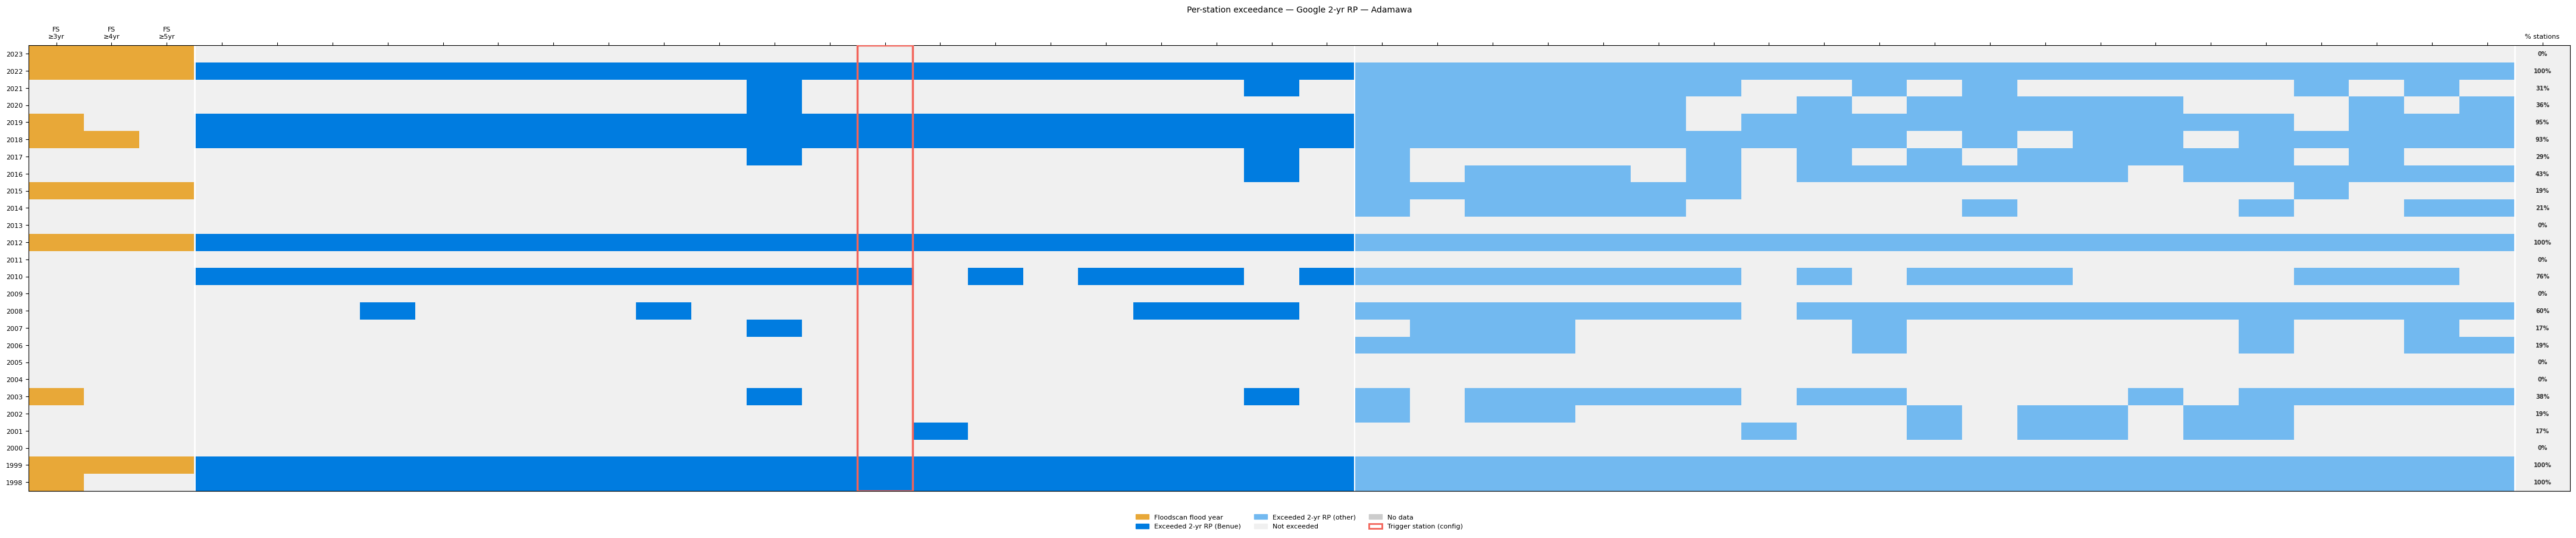

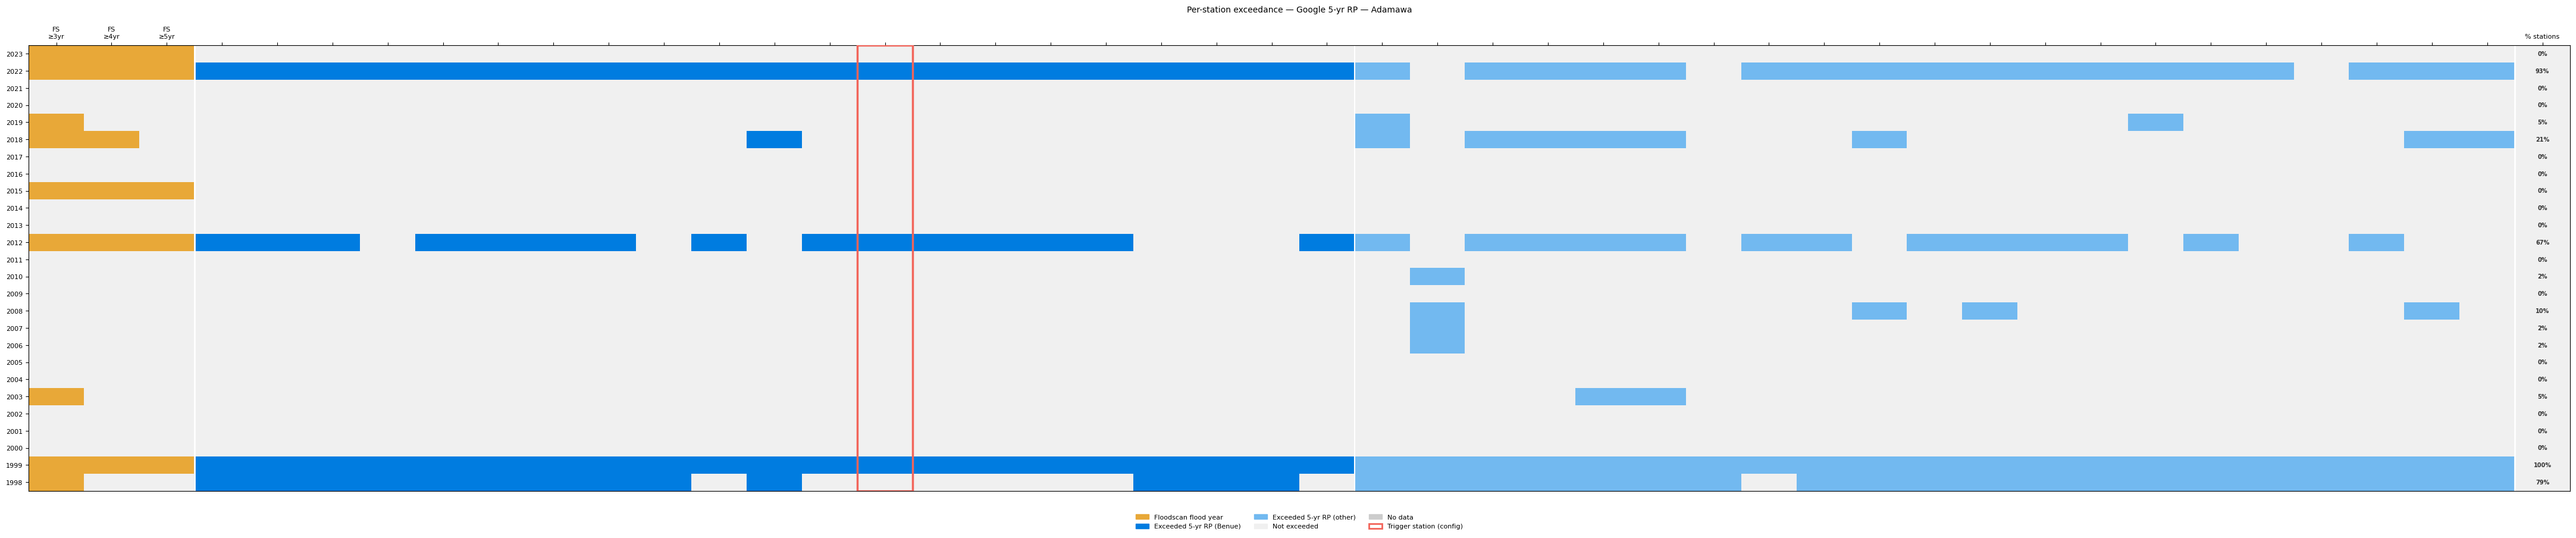

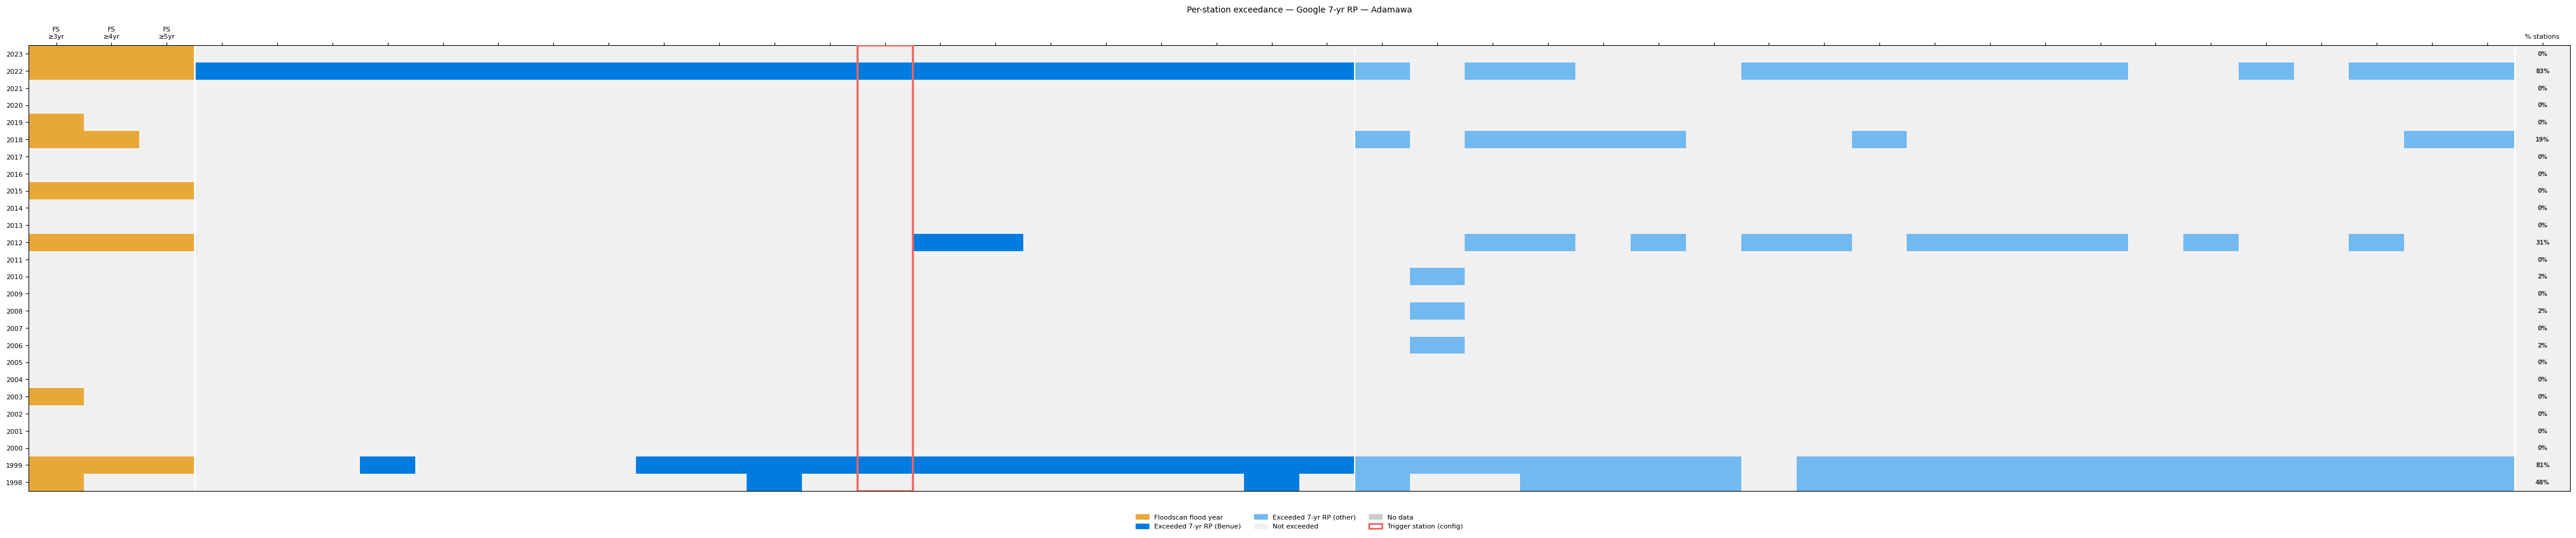

In [19]:
gauge_name_map = {
    gid: (name if pd.notna(name) else gid)
    for gid, name in gdf_stations.set_index("gauge_id")["site_name"].items()
}

# Sort stations: Benue river stations first, then others
is_benue = gdf_stations["river"].str.contains("Benue", case=False, na=False)
benue_gauge_set = set(gdf_stations[is_benue]["gauge_id"])
ordered_gauges = (
    gdf_stations[is_benue]["gauge_id"].tolist()
    + gdf_stations[~is_benue]["gauge_id"].tolist()
)
n_benue = len(gdf_stations[is_benue])

anchor_gauge = cfg["google_gauge"]
anchor_col_idx = (
    len(FS_RP_LEVELS) + ordered_gauges.index(anchor_gauge)
    if anchor_gauge in ordered_gauges else None
)

all_plot_years = sorted(
    set(df_annual["year"].unique()) & set(df_trig["year"]),
    reverse=True,
)

# 0=no data, 1=not reached, 2=Benue triggered (OCHA blue), 3=other triggered (light blue), 5=flood year
cmap_hm = mcolors.ListedColormap(["#CCCCCC", "#F0F0F0", "#007CE0", "#72B9F0", "#F2645A", "#E8A838"])
norm_hm = mcolors.BoundaryNorm([0, 1, 2, 3, 4, 5, 6], cmap_hm.N)

for station_rp in STATION_RP_LEVELS:
    # Per-station annual exceedance at this RP level, columns ordered Benue-first
    df_check = df_annual.merge(
        df_google_rp[df_google_rp["return_period"] == station_rp][["gauge_id", rp_value_col]],
        on="gauge_id", how="left",
    )
    df_check["triggered"] = (df_check["streamflow"] > df_check[rp_value_col]).astype(int)
    station_pivot = (
        df_check.pivot_table(index="year", columns="gauge_id", values="triggered", aggfunc="max")
        .reindex(index=all_plot_years, columns=ordered_gauges)
    )

    # Recode: NaN=0 (no data), 0=1 (not exceeded), 1=2 (Benue) or 3 (other)
    station_encoded = station_pivot.copy()
    for gid in station_pivot.columns:
        triggered_val = 2 if gid in benue_gauge_set else 3
        s = station_pivot[gid]
        station_encoded[gid] = np.where(s.isna(), 0, np.where(s == 1, triggered_val, 1))
    station_encoded = station_encoded.astype(int)

    # Fraction of stations exceeded per year (from cell-exceedance)
    frac_series = frac_exceeded[station_rp].reindex(all_plot_years, fill_value=np.nan)

    # Floodscan columns: 1=not flood year, 5=flood year
    fs_cols = pd.DataFrame(
        {
            f"FS\n≥{fs_rp}yr": [5 if yr in fs_event_years[fs_rp] else 1 for yr in all_plot_years]
            for fs_rp in FS_RP_LEVELS
        },
        index=all_plot_years,
    )

    frac_col = pd.DataFrame({"% stations": 1}, index=all_plot_years)

    plot_data = pd.concat(
        [fs_cols, station_encoded.rename(columns=gauge_name_map), frac_col], axis=1
    )
    n_cols = len(plot_data.columns)
    frac_col_idx = n_cols - 1

    fig, ax = plt.subplots(
        figsize=(max(8, 2 + n_cols * 0.9), max(6, len(all_plot_years) * 0.35))
    )
    ax.imshow(plot_data.values, cmap=cmap_hm, norm=norm_hm, aspect="auto")

    # Highlight the trigger station from config
    if anchor_col_idx is not None:
        ax.add_patch(plt.Rectangle(
            (anchor_col_idx - 0.5, -0.5), 1, len(all_plot_years),
            fill=False, edgecolor="#F2645A", linewidth=2.5, zorder=6,
        ))

    # Annotate fraction column with percentage text
    for row_i, frac_val in enumerate(frac_series):
        if not np.isnan(frac_val):
            ax.text(
                frac_col_idx, row_i, f"{frac_val:.0%}",
                ha="center", va="center", fontsize=7, fontweight="bold", color="#333333",
            )

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(plot_data.columns, fontsize=8)
    ax.set_yticks(range(len(all_plot_years)))
    ax.set_yticklabels(all_plot_years, fontsize=8)
    ax.xaxis.tick_top()

    # Separators: after FS cols | between Benue/other stations | before fraction col
    ax.axvline(x=len(FS_RP_LEVELS) - 0.5, color="white", linewidth=2)
    ax.axvline(x=len(FS_RP_LEVELS) + n_benue - 0.5, color="white", linewidth=1.5)
    ax.axvline(x=frac_col_idx - 0.5, color="white", linewidth=2)

    ax.set_title(f"Per-station exceedance — Google {station_rp}-yr RP — {STATE}", fontsize=10, pad=40)

    ax.legend(
        handles=[
            mpatches.Patch(color="#E8A838", label="Floodscan flood year"),
            mpatches.Patch(color="#007CE0", label=f"Exceeded {station_rp}-yr RP (Benue)"),
            mpatches.Patch(color="#72B9F0", label=f"Exceeded {station_rp}-yr RP (other)"),
            mpatches.Patch(color="#F0F0F0", label="Not exceeded"),
            mpatches.Patch(color="#CCCCCC", label="No data"),
            mpatches.Patch(facecolor="none", edgecolor="#F2645A", linewidth=2, label="Trigger station (config)"),
        ],
        loc="lower center", bbox_to_anchor=(0.5, -0.10), ncol=3, frameon=False, fontsize=8,
    )

    plt.tight_layout()
    plt.savefig(
        f"figures/{STATE.lower()}_station_exceedance_{station_rp}yr.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()

## Performance grid search

For every combination of (station RP level, fraction threshold), define a binary ensemble
trigger for each year: **triggered if fraction of stations exceeding the station RP ≥ fraction
threshold**.

Evaluate each trigger against Floodscan events at each Floodscan RP level. Report accuracy,
POD, FAR, precision, and F1.

In [20]:
all_years = sorted(set(df_annual["year"].unique()) & set(df_trig["year"]))

records = []
for station_rp in STATION_RP_LEVELS:
    for frac_thresh in FRACTION_THRESHOLDS:
        # Ensemble trigger: 1 if fraction of stations exceeding station_rp >= frac_thresh
        trigger_series = (frac_exceeded[station_rp].reindex(all_years, fill_value=0) >= frac_thresh).astype(int)

        for fs_rp in FS_RP_LEVELS:
            event_years = fs_event_years[fs_rp]

            tp = sum((trigger_series[y] == 1) and (y in event_years) for y in all_years)
            fp = sum((trigger_series[y] == 1) and (y not in event_years) for y in all_years)
            fn = sum((trigger_series[y] == 0) and (y in event_years) for y in all_years)
            tn = sum((trigger_series[y] == 0) and (y not in event_years) for y in all_years)

            pod = tp / (tp + fn) if (tp + fn) > 0 else np.nan
            far = fp / (tp + fp) if (tp + fp) > 0 else np.nan
            precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
            f1_denom = (pod or 0) + (precision or 0)
            f1 = 2 * pod * precision / f1_denom if f1_denom > 0 else np.nan

            records.append({
                "station_rp": station_rp,
                "frac_thresh": frac_thresh,
                "fs_rp": fs_rp,
                "n_activations": tp + fp,
                "pod": pod,
                "far": far,
                "precision": precision,
                "f1": f1,
                "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            })

df_results = pd.DataFrame(records)
print(df_results.groupby(["station_rp", "frac_thresh", "fs_rp"])[["pod", "far", "f1"]].first().round(2).to_string())

                               pod   far    f1
station_rp frac_thresh fs_rp                  
2          0.2         3      0.78  0.50  0.61
                       4      0.67  0.71  0.40
                       5      0.60  0.79  0.32
           0.4         3      0.67  0.33  0.67
                       4      0.67  0.56  0.53
                       5      0.60  0.67  0.43
           0.6         3      0.67  0.14  0.75
                       4      0.67  0.43  0.62
                       5      0.60  0.57  0.50
           0.8         3      0.67  0.00  0.80
                       4      0.67  0.33  0.67
                       5      0.60  0.50  0.55
           1.0         3      0.44  0.00  0.62
                       4      0.50  0.25  0.60
                       5      0.60  0.25  0.67
5          0.2         3      0.56  0.00  0.71
                       4      0.67  0.20  0.73
                       5      0.60  0.40  0.60
           0.4         3      0.44  0.00  0.62
             

## Results — heatmaps

For each Floodscan RP level, plot heatmaps of POD, FAR, and F1 score across the
(station RP level, fraction threshold) parameter space. This shows which parameter
combinations detect floods most reliably without too many false alarms.

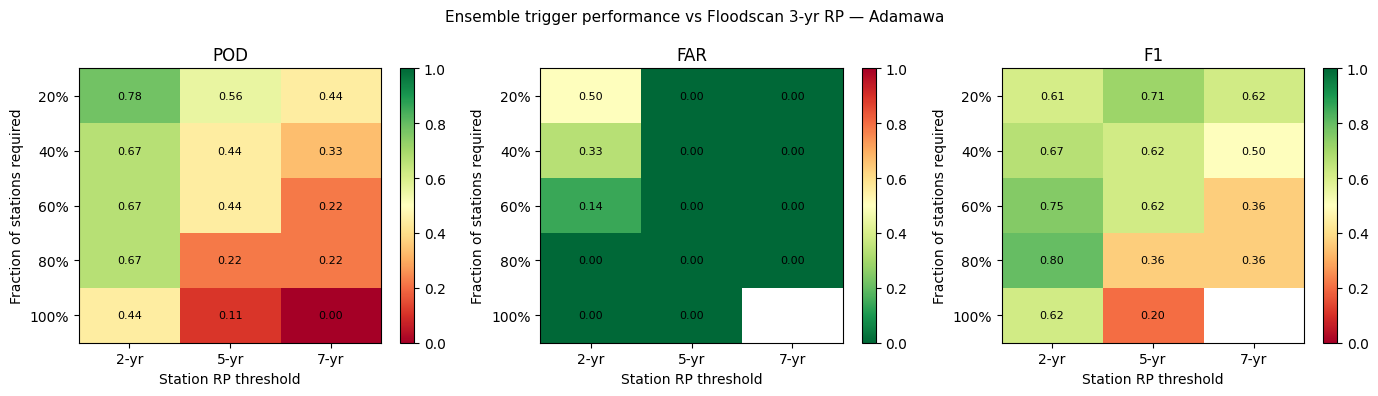

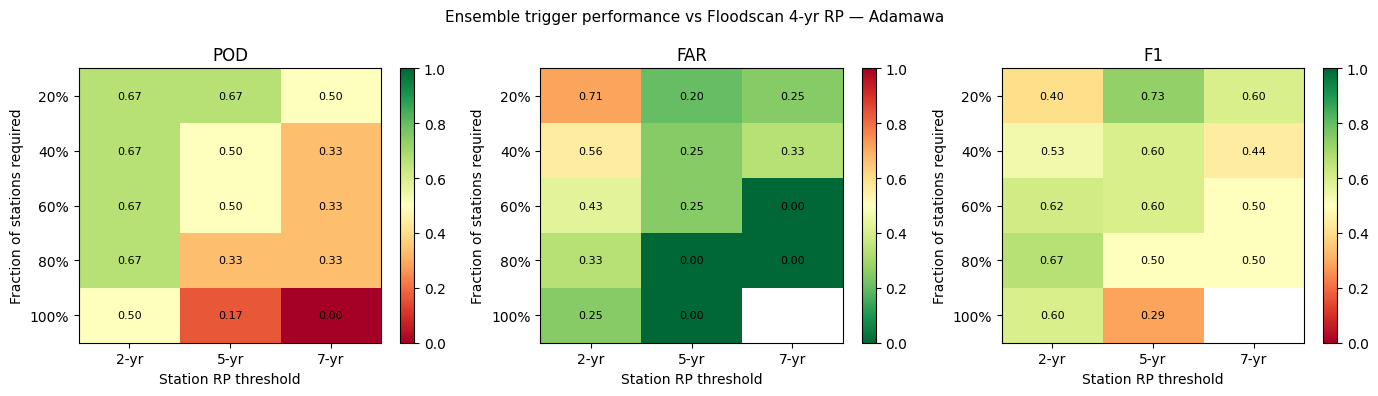

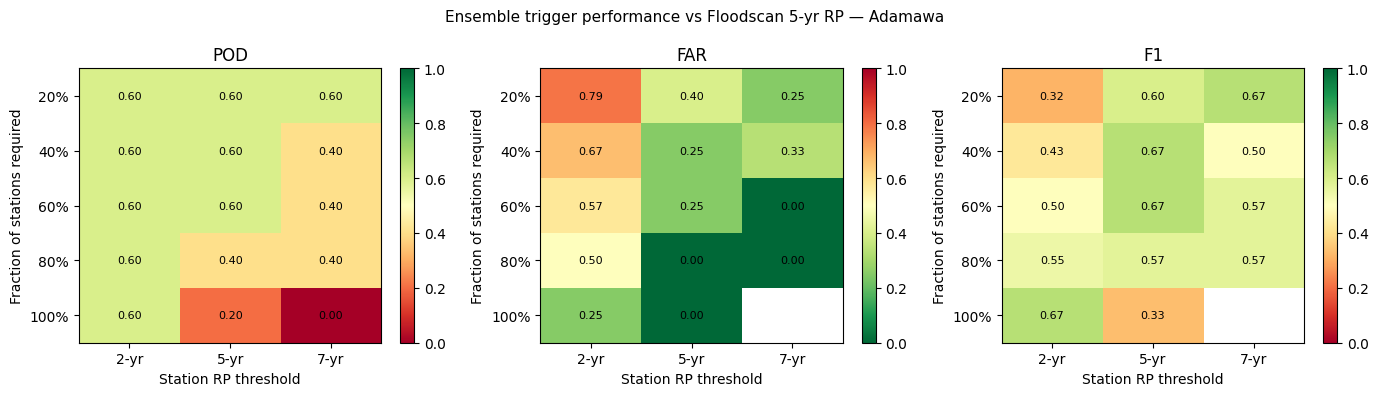

In [21]:
metrics = [("pod", "POD"), ("far", "FAR"), ("f1", "F1")]

for fs_rp in FS_RP_LEVELS:
    subset = df_results[df_results["fs_rp"] == fs_rp]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"Ensemble trigger performance vs Floodscan {fs_rp}-yr RP — {STATE}", fontsize=11)

    for ax, (metric, label) in zip(axes, metrics):
        pivot = subset.pivot(index="frac_thresh", columns="station_rp", values=metric)
        im = ax.imshow(pivot.values, vmin=0, vmax=1, cmap="RdYlGn" if metric != "far" else "RdYlGn_r",
                       aspect="auto")
        ax.set_xticks(range(len(STATION_RP_LEVELS)))
        ax.set_xticklabels([f"{r}-yr" for r in STATION_RP_LEVELS])
        ax.set_yticks(range(len(FRACTION_THRESHOLDS)))
        ax.set_yticklabels([f"{int(f*100)}%" for f in FRACTION_THRESHOLDS])
        ax.set_xlabel("Station RP threshold")
        ax.set_ylabel("Fraction of stations required")
        ax.set_title(label)
        plt.colorbar(im, ax=ax)

        # Annotate cells with values
        for i in range(len(FRACTION_THRESHOLDS)):
            for j in range(len(STATION_RP_LEVELS)):
                val = pivot.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(f"figures/{STATE.lower()}_ensemble_trigger_fs{fs_rp}yr.png", dpi=150, bbox_inches="tight")
    plt.show()

## Comparison — ensemble vs single-station trigger

Compare the best-performing ensemble configuration against the single-station trigger
used in other notebooks (Wuroboki / Makurdi at the fixed `glofas_thresh` / `google_thresh`).

Use the same Floodscan truth and report side-by-side POD, FAR, and F1 for each Floodscan
RP level.

In [22]:
# Single-station trigger: the anchor station (cfg["google_gauge"]) at cfg["google_thresh"]
ds_anchor = grrr.load_reanalysis(gauge=cfg["google_gauge"])
df_anchor = grrr.process_reanalysis(ds_anchor)
df_anchor["valid_time"] = pd.to_datetime(df_anchor["valid_time"])

single_trigger = (
    df_anchor[
        df_anchor["valid_time"].dt.month.isin(WET_MONTHS)
        & df_anchor["valid_time"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
    ]
    .assign(year=lambda x: x["valid_time"].dt.year)
    .groupby("year")["streamflow"].max()
    .gt(cfg["google_thresh"])
    .astype(int)
    .reindex(all_years, fill_value=0)
)

# Best ensemble config (by F1 averaged across Floodscan RP levels) — adjust as needed
best = df_results.groupby(["station_rp", "frac_thresh"])["f1"].mean().idxmax()
best_station_rp, best_frac = best
print(f"Best ensemble config: station RP {best_station_rp}-yr, fraction ≥ {best_frac:.0%}")

ensemble_trigger = (
    frac_exceeded[best_station_rp].reindex(all_years, fill_value=0) >= best_frac
).astype(int)

# Side-by-side comparison table
rows = []
for fs_rp in FS_RP_LEVELS:
    event_years = fs_event_years[fs_rp]
    for label, trig in [("Single station", single_trigger), ("Ensemble", ensemble_trigger)]:
        tp = sum((trig[y] == 1) and (y in event_years) for y in all_years)
        fp = sum((trig[y] == 1) and (y not in event_years) for y in all_years)
        fn = sum((trig[y] == 0) and (y in event_years) for y in all_years)
        pod = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        far = fp / (tp + fp) if (tp + fp) > 0 else np.nan
        prec = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        f1 = 2 * pod * prec / (pod + prec) if (pod and prec and (pod + prec) > 0) else np.nan
        rows.append({"fs_rp": fs_rp, "trigger": label, "pod": pod, "far": far, "f1": f1,
                     "activations": tp + fp})

pd.DataFrame(rows).set_index(["fs_rp", "trigger"]).round(2)

Best ensemble config: station RP 5-yr, fraction ≥ 20%


pod  far    f1  activations
fs_rp trigger                                     
3     Single station  0.56  0.0  0.71            5
      Ensemble        0.56  0.0  0.71            5
4     Single station  0.50  0.4  0.55            5
      Ensemble        0.67  0.2  0.73            5
5     Single station  0.60  0.4  0.60            5
      Ensemble        0.60  0.4  0.60            5